<a href="https://colab.research.google.com/github/jagan93550/Deep_learning/blob/main/hyperparmeter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

objective:
The objective of this project is to develop a Convolutional Autoencoder that efficiently compresses images into a compact latent representation and reconstructs them with minimal loss of visual quality. The project demonstrates how deep learning can reduce image storage requirements while preserving important image features, making it useful for applications such as image storage, transmission, and data compression.

Purpose:
To compress images into a compact latent representation while preserving important visual features.
To reconstruct high-quality images efficiently using a Convolutional Autoencoder.


In [1]:
import os
import shutil # libariray used for copying and moving files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from sklearn.model_selection import train_test_split

In [ ]:
#loading dataset from kaggle celeb -dataset
!pip install -q kaggle

from google.colab import files
files.upload()
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [2]:
!kaggle datasets download -d jessicali9530/celeba-dataset

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:08<00:00, 160MB/s]



In [3]:
import zipfile

with zipfile.ZipFile("celeba-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("celeba")

In [4]:
# Create a smaller dataset (5000 images)

import os
import shutil

# Correct image folder after extraction
source_folder = "celeba/img_align_celeba/img_align_celeba"

# Destination folder
destination_folder = "celeba_small/faces"

os.makedirs(destination_folder, exist_ok=True)

# Copy first 5000 images
images = sorted(os.listdir(source_folder))[:5000]

for img in images:
    shutil.copy(
        os.path.join(source_folder, img),
        os.path.join(destination_folder, img)
    )

print("Copied", len(images), "images successfully!")

Copied 5000 images successfully!


In [5]:
#data preprocessing
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32

In [6]:
datagen = ImageDataGenerator(
    rescale=1./255,    # scaling image dividing all by 255 ,
    validation_split=0.2)# used for teasting

In [7]:
# Load dataset
train_generator = datagen.flow_from_directory(
    "celeba_small",                # This code creates a training data generator that automatically loads
                                    # images from the dataset folder in batches for training the autoencode
    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="input",

    subset="training"
)

Found 4000 images belonging to 1 classes.


In [8]:
validation_generator = datagen.flow_from_directory(

    "celeba_small",
    target_size=IMAGE_SIZE,      # This code creates a validation data generator that loads the validation images from the celeba_small folder in batches for evaluating the autoencoder during training.
                                #The parameter class_mode="input" uses each input image as its own target, while subset="validation" selects only the validation portion of the dataset

    batch_size=BATCH_SIZE,

    class_mode="input",

    subset="validation"
)

Found 1000 images belonging to 1 classes.


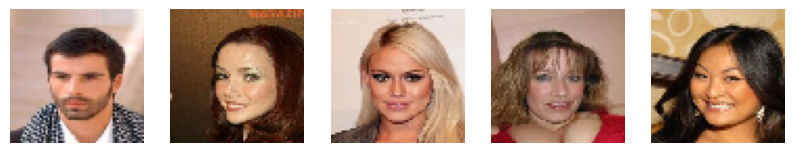

In [ ]:
#dispaly sample images
images, _=next(train_generator)
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1,5, i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()

In [41]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    BatchNormalization,
    Dropout
)
from tensorflow.keras.models import Model

input_img = Input(shape=(64,64,3))

# ---------------- Encoder ----------------

x = Conv2D(32,3,activation='relu',padding='same')(input_img)
x = BatchNormalization()(x)
x = Conv2D(32,3,activation='relu',padding='same')(x)
x = MaxPooling2D(2,padding='same')(x)

x = Conv2D(64,3,activation='relu',padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64,3,activation='relu',padding='same')(x)
x = MaxPooling2D(2,padding='same')(x)

x = Conv2D(128,3,activation='relu',padding='same')(x)
x = BatchNormalization()(x)
encoded = Dropout(0.2)(x)

# ---------------- Decoder ----------------

x = Conv2D(128,3,activation='relu',padding='same')(encoded)
x = BatchNormalization()(x)

x = UpSampling2D(2)(x)

x = Conv2D(64,3,activation='relu',padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64,3,activation='relu',padding='same')(x)

x = UpSampling2D(2)(x)

x = Conv2D(32,3,activation='relu',padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(32,3,activation='relu',padding='same')(x)

decoded = Conv2D(
    3,
    3,
    activation='sigmoid',
    padding='same'
)(x)

autoencoder = Model(input_img, decoded)


In [33]:
from tensorflow.keras.models import Model

autoencoder = Model(input_img, decoded)

In [44]:
datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2,

    rotation_range=10,

    zoom_range=0.1,

    width_shift_range=0.05,

    height_shift_range=0.05,

    horizontal_flip=True
)

In [42]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(
    learning_rate=0.0003
)

autoencoder.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [45]:
from tensorflow.keras.callbacks import *

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True
)

In [ ]:
# 16 16 64latent vector

In [46]:
history = autoencoder.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=60,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - accuracy: 0.7059 - loss: 0.5152 - val_accuracy: 0.7563 - val_loss: 0.6441 - learning_rate: 3.0000e-04
Epoch 2/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.7835 - loss: 0.4942 - val_accuracy: 0.7699 - val_loss: 0.5800 - learning_rate: 3.0000e-04
Epoch 3/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.7977 - loss: 0.4905 - val_accuracy: 0.7917 - val_loss: 0.5282 - learning_rate: 3.0000e-04
Epoch 4/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8107 - loss: 0.4881 - val_accuracy: 0.8122 - val_loss: 0.4909 - learning_rate: 3.0000e-04
Epoch 5/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.8124 - loss: 0.4874 - val_accuracy: 0.8117 - val_loss: 0.4863 - learning_rate: 3.0000e-04
Epoch 6/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8227 - loss: 0.4853 - val_accuracy: 0.8412 - val_loss: 0.4851 - learning_rate: 3.0000e-04
Epoch 7/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - 

In [14]:
#model summary

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
history = autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

Epoch 1/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8559 - loss: 0.4778 - val_accuracy: 0.8714 - val_loss: 0.4770 - learning_rate: 1.0000e-07
Epoch 2/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.8559 - loss: 0.4778 - val_accuracy: 0.8713 - val_loss: 0.4771 - learning_rate: 1.0000e-07
Epoch 3/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8575 - loss: 0.4778 - val_accuracy: 0.8722 - val_loss: 0.4771 - learning_rate: 1.0000e-07
Epoch 4/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8560 - loss: 0.4777 - val_accuracy: 0.8721 - val_loss: 0.4771 - learning_rate: 1.0000e-07
Epoch 5/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8568 - loss: 0.4778 - val_accuracy: 0.8712 - val_loss: 0.4771 - learning_rate: 1.0000e-07
Epoch 6/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8571 - loss: 0.4778 - val_accuracy: 0.8728 - val_loss: 0.4771 - learning_rate: 1.0000e-07
Epoch 7/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - acc

In [49]:
from tensorflow.keras.optimizers import Adam

learning_rates = [0.001, 0.0005, 0.0001]

results = {}

for lr in learning_rates:

    print("="*60)
    print(f"Training with Learning Rate = {lr}")

    optimizer = Adam(learning_rate=lr)

    autoencoder.compile(
        optimizer=optimizer,
        loss="binary_crossentropy"
    )

    history = autoencoder.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=10,
        verbose=1
    )

    results[lr] = history.history["val_loss"][-1]

print("\nValidation Loss Results")
print(results)

best_lr = min(results, key=results.get)
print(f"\nBest Learning Rate: {best_lr}")

Training with Learning Rate = 0.001
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.8223 - loss: 0.4828 - val_accuracy: 0.8218 - val_loss: 0.4855
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.8345 - loss: 0.4810 - val_accuracy: 0.7932 - val_loss: 0.4815
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8395 - loss: 0.4803 - val_accuracy: 0.8179 - val_loss: 0.4939
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8455 - loss: 0.4792 - val_accuracy: 0.8187 - val_loss: 0.4790
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8466 - loss: 0.4786 - val_accuracy: 0.8401 - val_loss: 0.4818
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8482 - loss: 0.4785 - val_accuracy: 0.8221 - val_loss: 0.4848
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8440 - loss: 0.4789 - val_accuracy: 0.7901 - val_loss: 0.4813
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accur

In [50]:
optimizer = Adam(learning_rate=best_lr)

autoencoder.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.8672 - loss: 0.4751 - val_accuracy: 0.8704 - val_loss: 0.4747 - learning_rate: 1.0000e-04
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.8688 - loss: 0.4751 - val_accuracy: 0.8523 - val_loss: 0.4746 - learning_rate: 1.0000e-04
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8665 - loss: 0.4750 - val_accuracy: 0.8707 - val_loss: 0.4747 - learning_rate: 1.0000e-04
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8703 - loss: 0.4753
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8697 - loss: 0.4750 - val_accuracy: 0.8653 - val_loss: 0.4746 - learning_rate: 1.0000e-04
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.8670 - loss: 0.4749 - val_accuracy: 0.8893 - val_loss: 0.4745 - learning_rate: 3.0000e-05
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accura

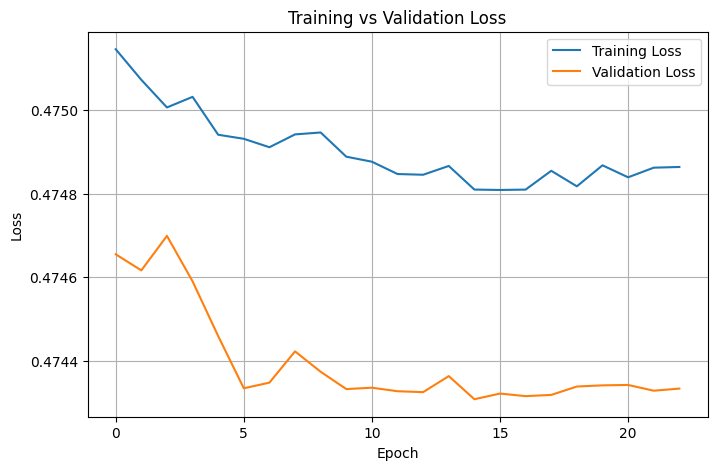

In [51]:
#plt loss graph
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()


In [52]:
#Ecaluate model
loss =autoencoder.evaluate(validation_generator)
print("Validation loss:",loss)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8917 - loss: 0.4743
Validation loss: [0.4743075966835022, 0.8917002081871033]


In [53]:
#Reconstruct Images

images,_=next(validation_generator)
reconstructed_images=autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 873ms/step


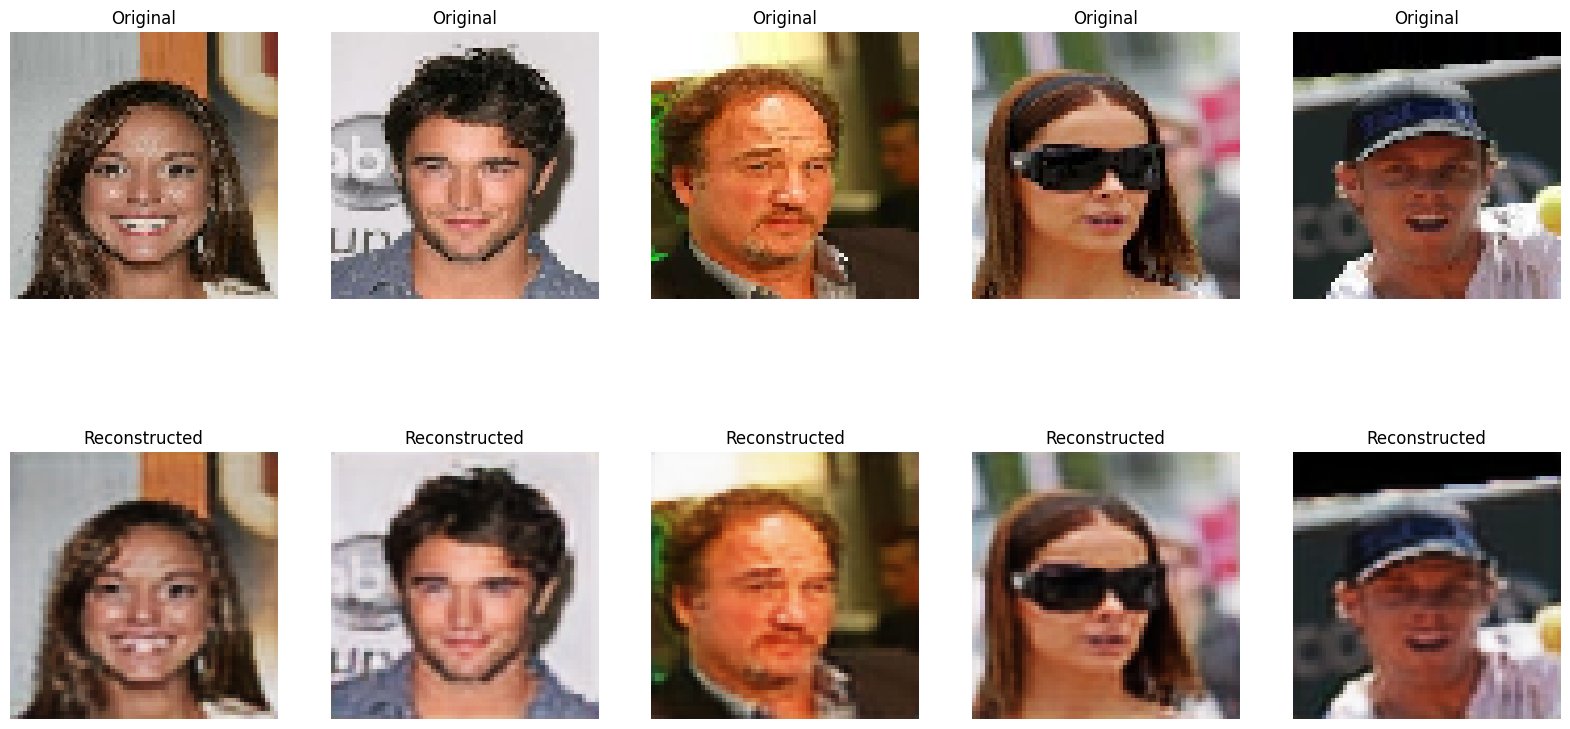

In [ ]:
n=5
plt.figure(figsize=(20,10))
for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(images[i])
    plt.title("Original")
    plt.axis('off')
    plt.subplot(2,n,i+1+n)
    plt.imshow(reconstructed_images[i])
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()